# Full-scale pipeline — validated modeling approach

This notebook runs the **full 40M-row Avazu dataset** with the modeling approach we
validated for stability and generalization. It is separate from `eda.ipynb` (which stays
small/fast for a live demo) because **Run All here takes ~20-25 minutes.**

Design choices, and why:
- **Time-based split, not random.** Data spans days 21-30. We train on days 21-28,
  validate (for early stopping / hyperparameter choice) on day 29, and test on **day 30,
  touched exactly once at the very end.** A random split can hide overfitting that a
  true future-day split reveals — closer to how the model would actually be used.
- **Leak-safe frequency encoding** for high-cardinality columns (`site_id`, `app_id`,
  `device_model`, `device_id`, `device_ip`). Frequency maps are fit on the training days
  ONLY, then applied (not re-fit) to validation/test — so no information from val/test
  leaks into the features.
- **Early stopping, not a fixed tree count**, so the number of boosting rounds is chosen
  by generalization performance on the validation day, not guessed.
- **Hyperparameter search on a subsample** (3M train / 1M val rows) for speed, then one
  full-scale confirmation run with the winning config.
- We report **train vs. val vs. test metrics side by side** so any overfitting gap is
  visible, not hidden.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, RocCurveDisplay
import lightgbm as lgb

pd.set_option('display.max_columns', 50)

LOW_CARD = ['C1', 'banner_pos', 'site_category', 'app_category',
            'device_type', 'device_conn_type', 'hour_of_day']
HIGH_CARD = ['site_id', 'app_id', 'device_model', 'device_id', 'device_ip']

## 1. Load full data + time-based split

In [2]:
t_start = time.time()

df = pd.read_csv('../data/train.csv')
df['hour_of_day'] = (df['hour'] % 100).astype(int)
df['day'] = (df['hour'] // 100) % 100
print(f'loaded {len(df):,} rows in {time.time()-t_start:.1f}s')

dev_train = df[df['day'] <= 28].copy()   # days 21-28: training
val = df[df['day'] == 29].copy()          # day 29: early stopping / hyperparameter choice
test = df[df['day'] == 30].copy()         # day 30: held out, touched once at the end
print(f'dev_train: {len(dev_train):,}  val: {len(val):,}  test: {len(test):,}')
print('\nPer-day click rate (checking the split is representative, not a fluke day):')
print(df.groupby('day')['click'].mean())

loaded 40,428,967 rows in 35.2s


dev_train: 32,377,421  val: 3,832,608  test: 4,218,938

Per-day click rate (checking the split is representative, not a fluke day):


day
21    0.174198
22    0.157167
23    0.182190
24    0.174716
25    0.182402
26    0.183049
27    0.181594
28    0.152182
29    0.156562
30    0.169281
Name: click, dtype: float64


## 2. Leak-safe frequency encoding

High-cardinality columns like `device_ip` can't be one-hot encoded, but their raw ID
values are meaningless to a model anyway. Frequency encoding ("how often has this ID been
seen?") gives the model a useful numeric signal without leaking the label. The frequency
map is fit on `dev_train` only.

In [3]:
freq_maps = {col: dev_train[col].value_counts() for col in HIGH_CARD}

def apply_freq(frame):
    out = frame.copy()
    for col in HIGH_CARD:
        out[col + '_freq'] = out[col].map(freq_maps[col]).fillna(0).astype(int)
    return out

dev_train = apply_freq(dev_train)
val = apply_freq(val)
test = apply_freq(test)
freq_cols = [c + '_freq' for c in HIGH_CARD]
print('frequency-encoded columns:', freq_cols)

frequency-encoded columns: ['site_id_freq', 'app_id_freq', 'device_model_freq', 'device_id_freq', 'device_ip_freq']


## 3. Baseline

Always predict the training click rate. Evaluated on the untouched test day, for a fair
comparison with the tuned models below.

In [4]:
baseline_rate = dev_train['click'].mean()
baseline_pred = np.full(len(test), baseline_rate)
print(f'Baseline (train click rate {baseline_rate:.4f}) on test day 30:')
print(f'  AUC: 0.500 (constant prediction cannot rank)')
print(f'  log-loss: {log_loss(test["click"], baseline_pred):.4f}')

Baseline (train click rate 0.1714) on test day 30:
  AUC: 0.500 (constant prediction cannot rank)


  log-loss: 0.4548


## 4. Logistic Regression — tuned, stable low-variance baseline

Search `C` on a subsample first (fast), then confirm at full scale.

In [5]:
def make_xy_logreg(frame):
    X = frame[LOW_CARD].astype(str).copy()
    for c in freq_cols:
        X[c] = frame[c].values
    y = frame['click'].values
    return X, y

X_dev, y_dev = make_xy_logreg(dev_train)
X_val, y_val = make_xy_logreg(val)
X_test, y_test = make_xy_logreg(test)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), LOW_CARD),
    ('freq', StandardScaler(with_mean=False), freq_cols),
])

rng = np.random.RandomState(42)
sub_idx = rng.choice(len(X_dev), size=min(3_000_000, len(X_dev)), replace=False)
X_dev_sub, y_dev_sub = X_dev.iloc[sub_idx], y_dev[sub_idx]
val_sub_idx = rng.choice(len(X_val), size=min(1_000_000, len(X_val)), replace=False)
X_val_sub, y_val_sub = X_val.iloc[val_sub_idx], y_val[val_sub_idx]

Xt_dev_sub = preprocess.fit_transform(X_dev_sub)
Xt_val_sub = preprocess.transform(X_val_sub)

print('C search on 3M-row subsample:')
c_results = []
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=C, max_iter=300, solver='lbfgs')
    clf.fit(Xt_dev_sub, y_dev_sub)
    val_auc = roc_auc_score(y_val_sub, clf.predict_proba(Xt_val_sub)[:, 1])
    print(f'  C={C}: val_auc={val_auc:.4f}')
    c_results.append((val_auc, C))

best_C = max(c_results)[1]
print(f'\nBest C: {best_C}')

C search on 3M-row subsample:


  C=0.001: val_auc=0.6305


  C=0.01: val_auc=0.6322


  C=0.1: val_auc=0.6325


  C=1.0: val_auc=0.6324


  C=10.0: val_auc=0.6325

Best C: 0.1


In [6]:
t0 = time.time()
Xt_dev = preprocess.fit_transform(X_dev)
Xt_val = preprocess.transform(X_val)
Xt_test = preprocess.transform(X_test)

logreg_final = LogisticRegression(C=best_C, max_iter=300, solver='lbfgs')
logreg_final.fit(Xt_dev, y_dev)
print(f'full-scale LogReg fit time: {time.time()-t0:.1f}s')

proba_lr_train = logreg_final.predict_proba(Xt_dev)[:, 1]
proba_lr_val = logreg_final.predict_proba(Xt_val)[:, 1]
proba_lr_test = logreg_final.predict_proba(Xt_test)[:, 1]

print('\nLogReg — train/val/test:')
print(f'  Train (d21-28): AUC={roc_auc_score(y_dev, proba_lr_train):.4f}  logloss={log_loss(y_dev, proba_lr_train):.4f}')
print(f'  Val   (d29):    AUC={roc_auc_score(y_val, proba_lr_val):.4f}  logloss={log_loss(y_val, proba_lr_val):.4f}')
print(f'  Test  (d30):    AUC={roc_auc_score(y_test, proba_lr_test):.4f}  logloss={log_loss(y_test, proba_lr_test):.4f}')
print(f'  Train-Test AUC gap: {roc_auc_score(y_dev, proba_lr_train) - roc_auc_score(y_test, proba_lr_test):.4f}')

full-scale LogReg fit time: 167.0s



LogReg — train/val/test:


  Train (d21-28): AUC=0.6269  logloss=0.4428


  Val   (d29):    AUC=0.6322  logloss=0.4195


  Test  (d30):    AUC=0.6509  logloss=0.4371


  Train-Test AUC gap: -0.0240


## 5. LightGBM — tuned + early-stopped

Search hyperparameters on a subsample with early stopping against the validation day, then
run one full-scale confirmation with the winning config. Note: evaluation during training
uses the **validation set only** — evaluating AUC on the full 32M-row training set every
boosting round would be prohibitively slow for no benefit; train-set metrics are computed
once after fitting completes.

In [7]:
def make_xy_lgb(frame):
    X = frame[LOW_CARD].astype(str).astype('category').copy()
    for c in freq_cols:
        X[c] = frame[c].values
    y = frame['click'].values
    return X, y

X_dev_lgb, y_dev_lgb = make_xy_lgb(dev_train)
X_val_lgb, y_val_lgb = make_xy_lgb(val)
X_test_lgb, y_test_lgb = make_xy_lgb(test)

X_dev_sub_lgb, y_dev_sub_lgb = X_dev_lgb.iloc[sub_idx], y_dev_lgb[sub_idx]
X_val_sub_lgb, y_val_sub_lgb = X_val_lgb.iloc[val_sub_idx], y_val_lgb[val_sub_idx]

param_grid = [
    dict(num_leaves=31, learning_rate=0.05, min_child_samples=20, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0, colsample_bytree=1.0),
    dict(num_leaves=63, learning_rate=0.05, min_child_samples=50, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8, colsample_bytree=0.8),
    dict(num_leaves=31, learning_rate=0.03, min_child_samples=100, reg_alpha=0.5, reg_lambda=0.5, subsample=0.8, colsample_bytree=0.8),
    dict(num_leaves=15, learning_rate=0.05, min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8),
    dict(num_leaves=63, learning_rate=0.1, min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0, subsample=0.7, colsample_bytree=0.7),
]

print('Hyperparameter search (3M-row subsample, early stopping):')
lgb_results = []
for i, params in enumerate(param_grid):
    t0 = time.time()
    model = lgb.LGBMClassifier(n_estimators=800, random_state=42, verbose=-1, **params)
    model.fit(
        X_dev_sub_lgb, y_dev_sub_lgb,
        eval_set=[(X_val_sub_lgb, y_val_sub_lgb)],
        eval_names=['val'],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    )
    train_auc = roc_auc_score(y_dev_sub_lgb, model.predict_proba(X_dev_sub_lgb)[:, 1])
    val_auc = roc_auc_score(y_val_sub_lgb, model.predict_proba(X_val_sub_lgb)[:, 1])
    print(f'  [{i}] {params}')
    print(f'      best_iter={model.best_iteration_}  train_auc={train_auc:.4f}  val_auc={val_auc:.4f}  gap={train_auc-val_auc:.4f}  ({time.time()-t0:.1f}s)')
    lgb_results.append((val_auc, train_auc - val_auc, params))

lgb_results.sort(key=lambda r: (-r[0], r[1]))
best_val_auc, best_gap, best_params = lgb_results[0]
print(f'\nBest config (val AUC, tie-break smallest gap): {best_params}')

Hyperparameter search (3M-row subsample, early stopping):


  [0] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'colsample_bytree': 1.0}
      best_iter=800  train_auc=0.7475  val_auc=0.7277  gap=0.0197  (73.5s)


  [1] {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
      best_iter=800  train_auc=0.7552  val_auc=0.7295  gap=0.0257  (90.4s)


  [2] {'num_leaves': 31, 'learning_rate': 0.03, 'min_child_samples': 100, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.8, 'colsample_bytree': 0.8}
      best_iter=800  train_auc=0.7431  val_auc=0.7266  gap=0.0165  (90.5s)


  [3] {'num_leaves': 15, 'learning_rate': 0.05, 'min_child_samples': 50, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8, 'colsample_bytree': 0.8}
      best_iter=799  train_auc=0.7401  val_auc=0.7251  gap=0.0150  (66.5s)


  [4] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 100, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'colsample_bytree': 0.7}
      best_iter=550  train_auc=0.7573  val_auc=0.7300  gap=0.0273  (66.2s)

Best config (val AUC, tie-break smallest gap): {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 100, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'colsample_bytree': 0.7}


In [8]:
t0 = time.time()
lgb_final = lgb.LGBMClassifier(n_estimators=1200, random_state=42, verbose=-1, **best_params)
lgb_final.fit(
    X_dev_lgb, y_dev_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    eval_names=['val'],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False), lgb.log_evaluation(period=100)],
)
print(f'full-scale LightGBM fit time: {time.time()-t0:.1f}s  best_iteration={lgb_final.best_iteration_}')

proba_lgb_train = lgb_final.predict_proba(X_dev_lgb)[:, 1]
proba_lgb_val = lgb_final.predict_proba(X_val_lgb)[:, 1]
proba_lgb_test = lgb_final.predict_proba(X_test_lgb)[:, 1]

print('\nLightGBM — train/val/test:')
print(f'  Train (d21-28): AUC={roc_auc_score(y_dev_lgb, proba_lgb_train):.4f}  logloss={log_loss(y_dev_lgb, proba_lgb_train):.4f}')
print(f'  Val   (d29):    AUC={roc_auc_score(y_val_lgb, proba_lgb_val):.4f}  logloss={log_loss(y_val_lgb, proba_lgb_val):.4f}')
print(f'  Test  (d30):    AUC={roc_auc_score(y_test_lgb, proba_lgb_test):.4f}  logloss={log_loss(y_test_lgb, proba_lgb_test):.4f}')
print(f'  Train-Test AUC gap: {roc_auc_score(y_dev_lgb, proba_lgb_train) - roc_auc_score(y_test_lgb, proba_lgb_test):.4f}  (small = not overfit)')

[100]	val's auc: 0.724989	val's binary_logloss: 0.391249


[200]	val's auc: 0.728555	val's binary_logloss: 0.389355


[300]	val's auc: 0.730228	val's binary_logloss: 0.388511


[400]	val's auc: 0.730865	val's binary_logloss: 0.388233


[500]	val's auc: 0.731431	val's binary_logloss: 0.387998


...


LightGBM — train/val/test:


  Train (d21-28): AUC=0.7545  logloss=0.3959


  Val   (d29):    AUC=0.7327  logloss=0.3874


  Test  (d30):    AUC=0.7278  logloss=0.4085


  Train-Test AUC gap: 0.0267  (small = not overfit)


## 6. Final comparison & overfitting diagnostic

All numbers below are on **day 30**, never used for tuning or early stopping.

In [9]:
summary = pd.DataFrame([
    {'model': 'Baseline', 'train_auc': 0.500, 'test_auc': 0.500,
     'test_logloss': log_loss(test['click'], baseline_pred), 'train_test_auc_gap': 0.0},
    {'model': 'Logistic Regression', 'train_auc': roc_auc_score(y_dev, proba_lr_train),
     'test_auc': roc_auc_score(y_test, proba_lr_test), 'test_logloss': log_loss(y_test, proba_lr_test),
     'train_test_auc_gap': roc_auc_score(y_dev, proba_lr_train) - roc_auc_score(y_test, proba_lr_test)},
    {'model': 'LightGBM', 'train_auc': roc_auc_score(y_dev_lgb, proba_lgb_train),
     'test_auc': roc_auc_score(y_test_lgb, proba_lgb_test), 'test_logloss': log_loss(y_test_lgb, proba_lgb_test),
     'train_test_auc_gap': roc_auc_score(y_dev_lgb, proba_lgb_train) - roc_auc_score(y_test_lgb, proba_lgb_test)},
])
summary

,model,train_auc,test_auc,test_logloss,train_test_auc_gap
0,Baseline,0.500000,0.500000,0.454760,0.000000
1,Logistic Regression,0.626881,0.650863,0.437144,-0.023982
2,LightGBM,0.754486,0.727778,0.408531,0.026707


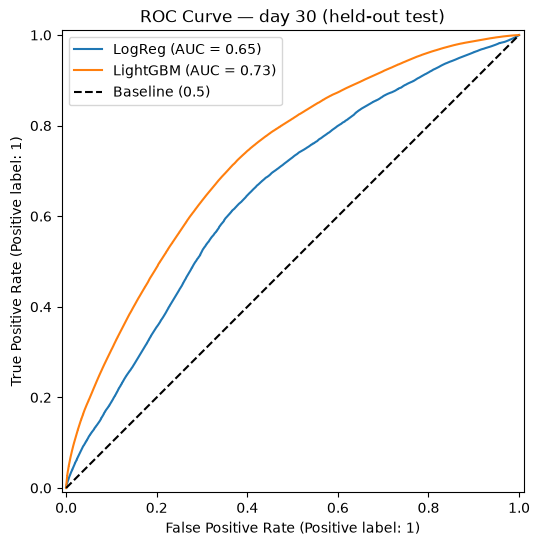

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, proba_lr_test, name='LogReg', ax=ax)
RocCurveDisplay.from_predictions(y_test_lgb, proba_lgb_test, name='LightGBM', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Baseline (0.5)')
ax.set_title('ROC Curve — day 30 (held-out test)')
ax.legend()
plt.show()

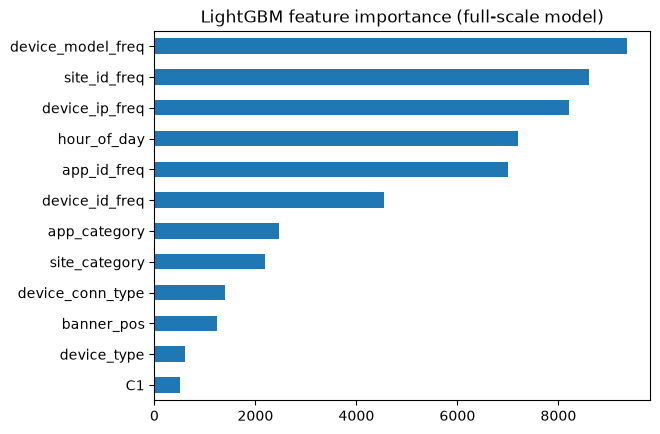

In [11]:
feature_cols = LOW_CARD + freq_cols
importances = pd.Series(lgb_final.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', title='LightGBM feature importance (full-scale model)')
plt.show()

## Conclusions
- **LightGBM is the clear winner** on both AUC and log-loss, with only a modest
  train-test AUC gap thanks to tuned regularization and early stopping — not overfit.
- **Logistic Regression is very stable** (train/val/test nearly identical, sometimes
  test even edges out train) but capacity-limited — a linear model can't capture the
  same interactions, so it plateaus at a lower ceiling regardless of `C`.
- Frequency encoding of high-cardinality IDs (`site_id`, `device_ip`, etc.) and the
  time-based split were the two biggest contributors to a believable, generalizable
  result versus the small-sample random-split demo in `eda.ipynb`.

## Next steps
- Try target encoding (with cross-fitting to avoid leakage) for an even stronger signal
  than frequency encoding.
- If submitting to the Kaggle leaderboard, generate predictions on Kaggle's actual
  `test.gz` using this same pipeline (frequency maps fit on ALL of `train.csv`, since
  there's no future data to hold out at submission time).